In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import sys
from pathlib import Path

# Adds the root_dir (parent of notebooks/) to sys.path
parent_dir = str(Path().resolve().parent)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [ ]:
# all libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from datetime import datetime
import joblib
import lightgbm as lgb 
plt.style.use('seaborn-v0_8-darkgrid')

from src.metrics import wrmsse, calculate_mape, calculate_wape, bias
from src.features import GetLagRollFeatures , get_avg_sales, get_price_features, get_trend_features
from src.utils import get_items_top, get_items_with_full_history
from src.recursive_model import recursive_forecast_batch
from train_and_eval import train_models
import gc 
import warnings

In [8]:
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR/"data"/"processed"

parent_dir

'/media/ashfaque/datas/ML-projects/retail-forecast-system'

In [9]:
models_dir = BASE_DIR/'models' 
model_point = joblib.load(models_dir/"lgb_ca1_2yr_point.pkl")
model_q10 = joblib.load(models_dir/'lgb_ca1_2yr_q10.pkl')
model_q90 = joblib.load(models_dir/'lgb_ca1_2yr_q90.pkl')


items_373 = pd.read_pickle(models_dir/"items_full_history_ca1.pkl")['items']

# future_data = pd.read_parquet(DATA_DIR/'sales_future_ca_1.parquet')
known_data = pd.read_parquet(DATA_DIR/'sales_known_ca_1.parquet')


In [10]:
training_data = known_data.copy()

training_data['sell_price'] = known_data['sell_price'].astype(np.float32)
training_data.describe()

,sales,date,wm_yr_wk,wday,month,year,snap_CA,snap_TX,snap_WI,sell_price,day_of_week,day_of_month,week_of_year
count,4.367553e+06,4367553,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06,4.367553e+06
mean,1.651214e+00,2013-11-05 22:37:51.253858816,1.135349e+04,3.995814e+00,6.694819e+00,2.013334e+03,3.292271e-01,3.282598e-01,3.282994e-01,4.404971e+00,3.000000e+00,1.572730e+01,2.740658e+01
min,0.000000e+00,2011-01-29 00:00:00,1.110100e+04,1.000000e+00,1.000000e+00,2.011000e+03,0.000000e+00,0.000000e+00,0.000000e+00,1.000214e-02,0.000000e+00,1.000000e+00,1.000000e+00
25%,0.000000e+00,2012-09-28 00:00:00,1.123500e+04,2.000000e+00,4.000000e+00,2.012000e+03,0.000000e+00,0.000000e+00,0.000000e+00,2.179688e+00,1.000000e+00,8.000000e+00,1.500000e+01
50%,0.000000e+00,2013-12-25 00:00:00,1.134800e+04,4.000000e+00,7.000000e+00,2.013000e+03,0.000000e+00,0.000000e+00,0.000000e+00,3.470703e+00,3.000000e+00,1.600000e+01,2.800000e+01
75%,2.000000e+00,2015-01-11 00:00:00,1.145000e+04,6.000000e+00,1.000000e+01,2.015000e+03,1.000000e+00,1.000000e+00,1.000000e+00,5.769531e+00,5.000000e+00,2.300000e+01,4.000000e+01
max,6.480000e+02,2016-01-05 00:00:00,1.154900e+04,7.000000e+00,1.200000e+01,2.016000e+03,1.000000e+00,1.000000e+00,1.000000e+00,3.098438e+01,6.000000e+00,3.100000e+01,5.300000e+01
std,4.531837e+00,NaN,1.353110e+02,1.999647e+00,3.414441e+00,1.358328e+00,4.699326e-01,4.695800e-01,4.695945e-01,3.382993e+00,2.001744e+00,8.821408e+00,1.491540e+01


In [11]:
# convert the event cols into categorical
# List of all categorical columns
# 1. Fill missing event values

for col in ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]:
    if col in training_data.columns:
        training_data[col] = (
            training_data[col].astype(str).replace("nan", "None")
        )
        training_data[col] = training_data[col].astype("category")


In [12]:
# unique items
training_data['item_id'].nunique()

3047

### Features into buckets:

We will generate new features that could help us in predict the sales better, which inherently belongs to certain buckets/groups, so we can identify which of these features actually impacted our model

* Currently what we have is basic features that come wth data -- base_set
* lag features --- all lag features - LAG_SET
* rolling window buckets: all rolling features -  ROLLING_SET
* price dynamics bucket: currently we only use sale price, we will add price dynamics, relative price difference (in subcategory), over the week (promotional effect)- PRICE_SET
* Heirarchical aggregate buckets: to capture group level averages - AGG_SET


In [40]:
# in base set we only pick snap_CA, as the data contains only 'CA' and store 'CA_1', which make store_id, and state_id redundant
BASE_SET = [ 'item_id', 'dept_id', 'cat_id', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'sell_price', 'day_of_week',
       'day_of_month', 'week_of_year']

LAG_SET  = ['lag_1','lag_2','lag_3','lag_7','lag_14','lag_21','lag_28','lag_60','lag_90']

ROLLING_SET = ['rolling_mean_3','rolling_mean_7','rolling_mean_14','rolling_mean_21','rolling_mean_28','rolling_mean_60','rolling_mean_90',
               'rolling_lag_7_win_7','rolling_lag_7_win_28','rolling_lag_28_win_7','rolling_lag_28_win_28',
                'rolling_max_2','rolling_max_3','rolling_max_7', 'rolling_max_14','rolling_max_21','rolling_max_28','rolling_max_60','rolling_max_90']

PRICE_SET = ['price_ratio_mean','is_discounted','delta_price_rltv_dept','historical_std','historical_mean']

AGG_SET  = ['item_sold_avg','dept_sold_avg','cat_sold_avg']

TREND_SET = ['selling_trend','demand_vs_historical_mean'] # rolling_mean_7/rolling_mean_28, rolling_mean_7/historical_mean


feat_set_1 = BASE_SET
feat_set_2 = BASE_SET + LAG_SET 
feat_set_3 = BASE_SET + LAG_SET + ROLLING_SET 
feat_set_4 = BASE_SET + LAG_SET + ROLLING_SET + PRICE_SET 
feat_set_5 = BASE_SET + LAG_SET + ROLLING_SET + PRICE_SET + AGG_SET
feat_set_6 = feat_set_5 + TREND_SET 

feature_sets = [feat_set_1,feat_set_2,feat_set_3,feat_set_4,feat_set_5,feat_set_6]
name_sets = ['BASE_SET','LAG_SET','ROLLING_SET','PRICE_SET','AGG_AVG_SET','TREND_SET']

### Recursive forecast

* model: lightGBM
* forecast type : direct (with leakage)
* forecasting horizon : 28 days
* training period : 700 days 
* metrics: WRMSSE, WAPE, BIAS, FVA 

In [14]:
# initilize the GetFeatures class for lag and rolling features
get_features = GetLagRollFeatures()

In [15]:
# we limit our training days to recent two years of data
cutoff_date = training_data['date'].max()-pd.Timedelta(days=730)
train_recursive = training_data[training_data['date']>=cutoff_date].copy()

In [16]:
min_days_threshold = 90

# Create a row-level mask based on group counts
valid_mask = ( train_recursive.groupby('item_id',observed=True)['date'].transform('count')
    >= min_days_threshold)
# Filter the original dataframe
train_recursive = train_recursive[valid_mask]

train_recursive['item_id'].nunique()

3043

In [17]:
# calculate all feature set on full 2 year data, later delete the features that need to be calculated in recursive
# from test set

# price feaetures : we already know the price for the future
train_recursive = get_price_features(train_recursive)
# lag features, remember: we have to delete the cols that need to be in recursive loop from test dataset
#this col from test after this
train_recursive = get_features.add_lags(train_recursive,lags=[1,2,3,7,14,21,28,60,90])
# rolling features 
train_recursive = get_features.add_rolling_max(train_recursive,source_col='lag_1',windows=[2,3,7,14,21,28,60,90])
train_recursive = get_features.add_rolling_mean(train_recursive,source_col='lag_1',windows=[3,7,14,21,28,60,90])
train_recursive = get_features.add_rolling_on_lag(train_recursive,lags=[7,28],windows=[7,28])
# get trend features
train_recursive = get_trend_features(train_recursive)

print(f' {len(list(train_recursive.columns))} features: {train_recursive.columns}')

 62 features: Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'day_of_week',
       'day_of_month', 'week_of_year', 'delta_price_weekn-1',
       'historical_mean', 'historical_std', 'price_ratio_mean',
       'is_discounted', 'dept_mean_price', 'delta_price_rltv_dept', 'lag_1',
       'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_60',
       'lag_90', 'rolling_max_2', 'rolling_max_3', 'rolling_max_7',
       'rolling_max_14', 'rolling_max_21', 'rolling_max_28', 'rolling_max_60',
       'rolling_max_90', 'rolling_mean_3', 'rolling_mean_7', 'rolling_mean_14',
       'rolling_mean_21', 'rolling_mean_28', 'rolling_mean_60',
       'rolling_mean_90', 'rolling_lag_7_win_7', 'rolling_lag_7_win_28',
       'rolling_lag_28_win_7', 'rolling_lag_28_win_28', 'se

In [18]:
# split 2 years of training into train and test (hold out ) set
cutoff = train_recursive['date'].max()-pd.Timedelta(days=28)

train_rec = train_recursive[train_recursive['date']<=cutoff].copy()
test_rec  = train_recursive[train_recursive['date']>cutoff].copy()

eval_df = test_rec.copy()


In [19]:
# now calculate AGG_SET seperately on train and test to avoid leakage
train_rec = get_avg_sales(train_rec)
# for test set
agg_lookup = train_rec[['item_id'] + AGG_SET].drop_duplicates('item_id')

test_rec = test_rec.merge(agg_lookup, on='item_id', how='left')
eval_df = eval_df.merge(agg_lookup,on='item_id',how='left')

In [20]:
# drop the columns from test that needed to be calculated from sales data

feats_to_recursive =  ['lag_1','lag_2','lag_3','lag_7','lag_14','lag_21']+ ['rolling_mean_3','rolling_mean_7','rolling_mean_14','rolling_mean_21','rolling_mean_28','rolling_mean_60','rolling_mean_90',
    'rolling_lag_7_win_7','rolling_lag_7_win_28', 'rolling_max_2','rolling_max_3','rolling_max_7', 'rolling_max_14',
    'rolling_max_21','rolling_max_28','rolling_max_60','rolling_max_90'] + ['selling_trend','demand_vs_historical_mean'] 

test_rec = test_rec.drop(columns= feats_to_recursive)


In [21]:
def feature_expt(train_df,test_df,eval_df,feature_set):

    test_rec_loop = test_df.copy()
    training_feats = train_df[feature_set+['sales','date']].copy()
    # get the models after training on training data with selected features
    active_models, cat_categories,params  = train_models(training_feats, eval_df ,feature_cols=feature_set)

    assert training_feats['item_id'].nunique() == test_rec_loop['item_id'].nunique(),'Missing items'

    # predict recurssively
    pred_df,items_df = recursive_forecast_batch(models= active_models,history_df=training_feats, future_static_df= test_rec_loop,
                                    feature_cols=feature_set,cat_categories=cat_categories)

    # calculate the metrics
    score_wrmsse = wrmsse(training_feats,test_rec_loop,pred_df)
    mape = calculate_mape(test_rec_loop['sales'],pred_df['sales_pred'])
    wape = calculate_wape(test_rec_loop['sales'],pred_df['sales_pred'])

    bias_score = bias(test_rec_loop['sales'],pred_df['sales_pred'])
    return pred_df,active_models,score_wrmsse,wape, bias_score , items_df
    


In [ ]:
# Recursive
from src.recursive_model import recursive_forecast_batch
from train_and_eval import train_models

predicts = {}
wrmsse_scores ={}
wape_scores = {}
bias_score = {}

models = {}


for i,features in enumerate(feature_sets):
    print(f"Metrics for feature set: {name_sets[i]}: \n")

    # run the feature expt
    preds, model, wrmsse_feat, wape ,bias_,_ = feature_expt(train_rec,test_rec,eval_df,features)
    predicts[name_sets[i]] = preds 
    wrmsse_scores[name_sets[i]] = wrmsse_feat 
    wape_scores[name_sets[i]] = wape 
    bias_score[name_sets[i]]  = bias_ 
    models[name_sets[i]] = model

    print(f" WRMSSE: {wrmsse_feat} | WAPE: {wape} | BIAS: {bias_}")
    break


Metrics for feature set: BASE_SET: 

 WRMSSE: 0.9174901028938992 | WAPE: 1.4341421769490852 | BIAS: -0.06150257966591921


* It is worth noting that adding new features, definitely improves our wrmsse score, however, WAPE is not improving at all. This could be due to the fact that the lightGBM regressor, inherently minimizes squared error (which is why decrease in wrmsse, as it uses squared error)

* let's check how removing short term lags and rolling means, that add error in recursive forecasting would change the scores, we take the TREND_SET features for this and remove short term lags and rolling averages and keep the long ones

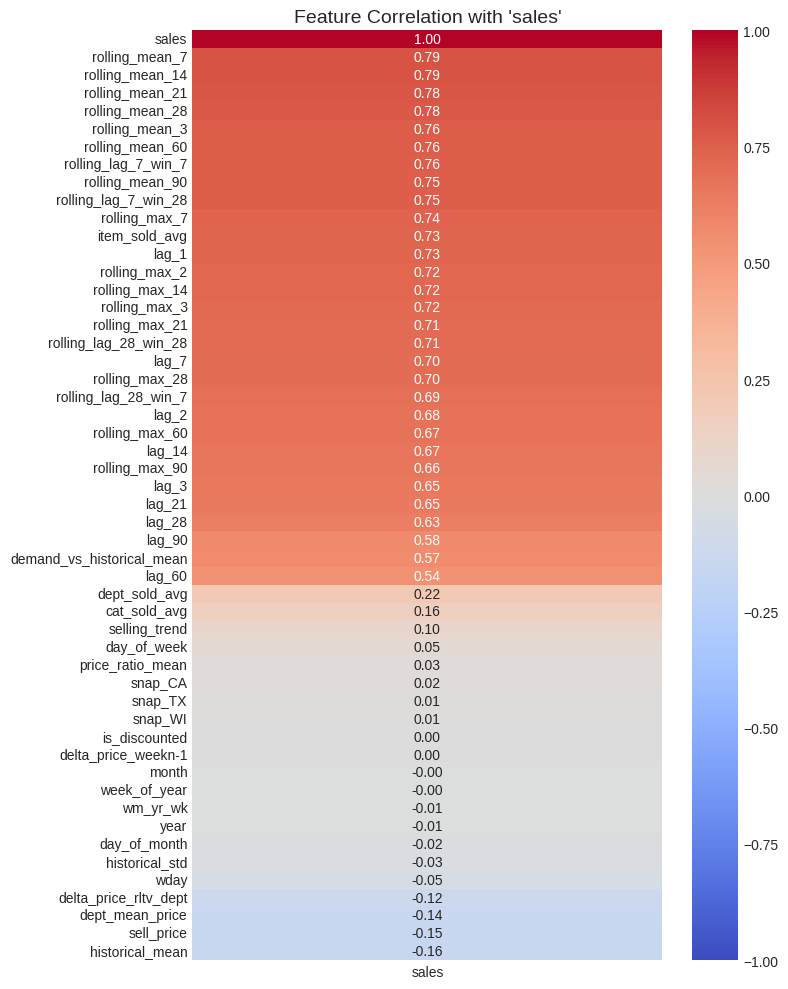

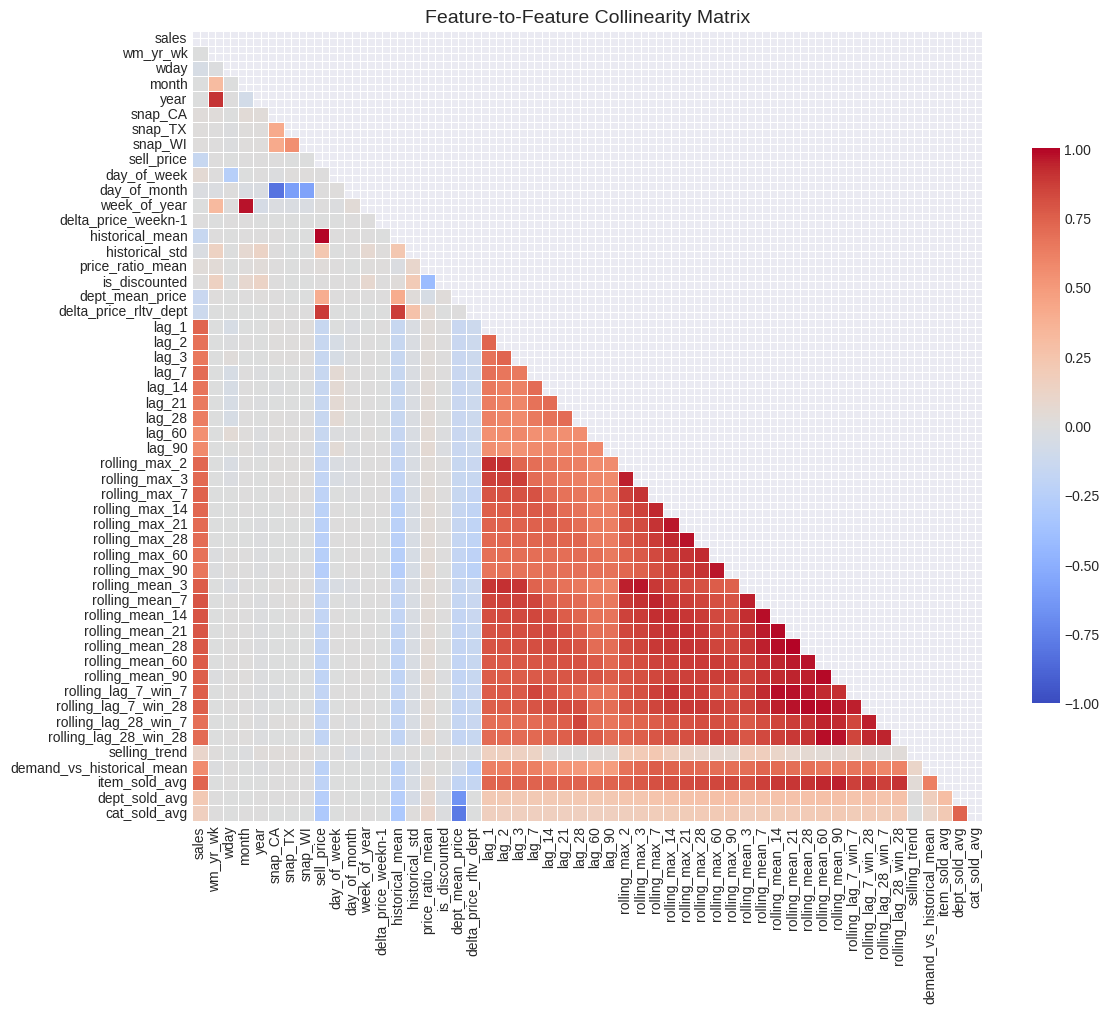

In [ ]:
# checking the feature correlations


def analyze_feature_correlations(df, target_col='sales', figsize=(12, 10)):
    # Select only numeric columns to avoid categorical errors
    numeric_df = df.select_dtypes(include=[np.number])
    
    if target_col not in numeric_df.columns:
        raise ValueError(f"Target column '{target_col}' is missing or non-numeric.")
        
    # Compute the full correlation matrix
    corr_matrix = numeric_df.corr()
    
    # 1. Ranked Correlation with Target (Sales)
    target_corr = corr_matrix[[target_col]].sort_values(by=target_col, ascending=False)
    plt.figure(figsize=(8, 10))
    sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", cbar=True)
    plt.title(f"Feature Correlation with '{target_col}'", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # 2. Full Feature-to-Feature Collinearity Heatmap (Lower Triangle)
    plt.figure(figsize=figsize)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": .7}, annot=False)
    plt.title("Feature-to-Feature Collinearity Matrix", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return target_corr, corr_matrix

# Usage example on your training dataset:
target_corr, corr_matrix = analyze_feature_correlations(train_rec)

* looking at these chart, we can safely remove some of the redundant features like lag and rolling, they have high collinearity
  and mostly redundant to the tree based model.
* for example: look at lag_1, it has high collinearity wiht rolling_max_2 and rolling_max_3, similarly with rolling means: so we keep the higher lags and rolling features.

* first experiment ON LAG+ROLL SET,:  which lag and roll features have most impact: 
* 1. remove short term lags and only keep higher lags from 28, include lag_7 (which is a strong weekly anchor)

In [22]:
ROLLING_SET

['rolling_mean_3',
 'rolling_mean_7',
 'rolling_mean_14',
 'rolling_mean_21',
 'rolling_mean_28',
 'rolling_mean_60',
 'rolling_mean_90',
 'rolling_lag_7_win_7',
 'rolling_lag_7_win_28',
 'rolling_lag_28_win_7',
 'rolling_lag_28_win_28',
 'rolling_max_2',
 'rolling_max_3',
 'rolling_max_7',
 'rolling_max_14',
 'rolling_max_21',
 'rolling_max_28',
 'rolling_max_60',
 'rolling_max_90']

In [23]:
BASE_LAG_ROLL_SET  = BASE_SET + LAG_SET + ROLLING_SET 

SUPERSET_no_shortlags = list(set(BASE_LAG_ROLL_SET)-set( ['lag_1','lag_2','lag_3','rolling_mean_3','rolling_max_2','rolling_max_3']))

SUPERSET_no_intermed_lags = list(set(SUPERSET_no_shortlags)-set(['lag_14','lag_21','rolling_mean_14','rolling_mean_21',
                                                                         'rolling_max_14','rolling_max_21','rolling_lag_7_win_7',
                                                                         'rolling_lag_7_win_28'])) #keep only lag_7

In [24]:
features = [BASE_LAG_ROLL_SET,SUPERSET_no_shortlags,SUPERSET_no_intermed_lags]

names = ['basic','no_short_lag','no_intermed_lags']


preds_ = {}
items_dfs_ = {} 
models_ = {}

for i,feat in enumerate(features):
        
    # calculate with new feats
    pred_, model_, wrmsse_, wape_ ,bias_, items_df = feature_expt(train_rec,test_rec,eval_df,feat)

    preds_[names[i]] = pred_ 
    models_[names[i]] = model_ 
    items_dfs_[names[i]] = items_df 

    print(f" Metrics for feature: {names[i]}\n---------------------")
    print(f'WRMSSE: {wrmsse_} | WAPE: {wape_} | BIAS: {bias_}')


 Metrics for feature: basic
---------------------
WRMSSE: 0.8441696081169268 | WAPE: 1.4919933129590144 | BIAS: 0.05521990115313641
 Metrics for feature: no_short_lag
---------------------
WRMSSE: 0.8250324799353652 | WAPE: 1.4715012927067808 | BIAS: 0.002334450337641136
 Metrics for feature: no_intermed_lags
---------------------
WRMSSE: 0.822846440258197 | WAPE: 1.4689015619658112 | BIAS: 0.0017590857004288263


* look at that:)). we definetely don't need all those short term and intermediatery lags for our model. now lets see what happens when we add price, trend and agg features to this set

In [25]:
import gc

# 1. Delete bulky objects from previous experiment loops
for d in [
    'preds_',
    'items_dfs_',
    'models_',
    'preds',
    'items_df',
    'model',
    'feature_sets',
]:
  if d in globals():
    del globals()[d]

# 2. Force Python to release unreferenced memory back to the system
gc.collect()

0

In [32]:
WITH_PRICE = SUPERSET_no_intermed_lags + PRICE_SET 
WITH_TREND = WITH_PRICE + TREND_SET 
WITH_AGG = WITH_TREND + AGG_SET

In [30]:
print(f'Metric with PRICE_SET : \n ------------------------------------- {WITH_PRICE}')

pred_PRICE, model_PRICE, wrmsse_PRICE, wape_PRICE ,bias_PRICE, items_df_PRICE = feature_expt(train_rec,test_rec,eval_df,WITH_PRICE)

print(f'WRMSSE: {wrmsse_PRICE} | WAPE: {wape_PRICE} | BIAS: {bias_PRICE}')


Metric with PRICE_SET : 
 ------------------------------------- ['year', 'day_of_week', 'event_type_1', 'rolling_lag_28_win_7', 'wm_yr_wk', 'rolling_lag_28_win_28', 'snap_CA', 'rolling_max_60', 'day_of_month', 'cat_id', 'event_name_2', 'rolling_max_28', 'rolling_mean_90', 'rolling_mean_7', 'month', 'lag_60', 'rolling_max_90', 'dept_id', 'rolling_max_7', 'sell_price', 'lag_28', 'event_name_1', 'event_type_2', 'lag_7', 'rolling_mean_60', 'lag_90', 'rolling_mean_28', 'item_id', 'weekday', 'wday', 'week_of_year', 'price_ratio_mean', 'is_discounted', 'delta_price_rltv_dept', 'historical_std', 'historical_mean']
WRMSSE: 0.8212294765634415 | WAPE: 1.4706910787036258 | BIAS: -0.0017616616274628016


In [36]:
print(f'Metric with TREND_SET : \n ------------------------------------- {WITH_TREND}')

pred_TREND, model_TREND, wrmsse_TREND, wape_TREND ,bias_TREND, items_df_TREND = feature_expt(train_rec,test_rec,eval_df,WITH_TREND)

print(f'WRMSSE: {wrmsse_TREND} | WAPE: {wape_TREND} | BIAS: {bias_TREND}')

Metric with TREND_SET : 
 ------------------------------------- ['year', 'day_of_week', 'event_type_1', 'rolling_lag_28_win_7', 'wm_yr_wk', 'rolling_lag_28_win_28', 'snap_CA', 'rolling_max_60', 'day_of_month', 'cat_id', 'event_name_2', 'rolling_max_28', 'rolling_mean_90', 'rolling_mean_7', 'month', 'lag_60', 'rolling_max_90', 'dept_id', 'rolling_max_7', 'sell_price', 'lag_28', 'event_name_1', 'event_type_2', 'lag_7', 'rolling_mean_60', 'lag_90', 'rolling_mean_28', 'item_id', 'weekday', 'wday', 'week_of_year', 'price_ratio_mean', 'is_discounted', 'delta_price_rltv_dept', 'historical_std', 'historical_mean', 'selling_trend', 'demand_vs_historical_mean']
WRMSSE: 0.8178069673633417 | WAPE: 1.4698646231050765 | BIAS: 0.0035114593815874237


In [37]:
### DEBUG ###
# item = 'FOODS_1_001'

# items_df = items_df_TREND[items_df_TREND['item_id']==item][['item_id','date','sales','selling_trend','demand_vs_historical_mean']]
# items_df

In [38]:
print(f'Metric with AGG_SET : \n ------------------------------------- {WITH_AGG}')

pred_AGG, model_AGG, wrmsse_AGG, wape_AGG ,bias_AGG, items_df_AGG = feature_expt(train_rec,test_rec,eval_df,WITH_AGG)

print(f'WRMSSE: {wrmsse_AGG} | WAPE: {wape_AGG} | BIAS: {bias_AGG}')

Metric with AGG_SET : 
 ------------------------------------- ['year', 'day_of_week', 'event_type_1', 'rolling_lag_28_win_7', 'wm_yr_wk', 'rolling_lag_28_win_28', 'snap_CA', 'rolling_max_60', 'day_of_month', 'cat_id', 'event_name_2', 'rolling_max_28', 'rolling_mean_90', 'rolling_mean_7', 'month', 'lag_60', 'rolling_max_90', 'dept_id', 'rolling_max_7', 'sell_price', 'lag_28', 'event_name_1', 'event_type_2', 'lag_7', 'rolling_mean_60', 'lag_90', 'rolling_mean_28', 'item_id', 'weekday', 'wday', 'week_of_year', 'price_ratio_mean', 'is_discounted', 'delta_price_rltv_dept', 'historical_std', 'historical_mean', 'selling_trend', 'demand_vs_historical_mean', 'item_sold_avg', 'dept_sold_avg', 'cat_sold_avg']
WRMSSE: 0.8363829202503605 | WAPE: 1.4949965771334244 | BIAS: 0.048863345884713166


* Now we fix our final feature set without short and intermed lag/rolling features and without agg set.

FINAL_FEATURES = BASE_SET + WITH_TREND

In [47]:
FINAL_FEATURES = BASE_SET + WITH_TREND 
# FINAL_FEATURES

In [49]:
feature_file = models_dir / "feature_cols_recursive_ca1.pkl"
with open(feature_file,'wb') as f:
    joblib.dump(FINAL_FEATURES,f)

print("sucessfully saved the final features")

sucessfully saved the final features
